<a href="https://colab.research.google.com/github/os1187/EDA-E1-26-27/blob/main/Assessment_4_25BAI0058.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/credit card.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (5000, 14)
   ID  Age  Experience  Income  ZIP Code  Family  CCAvg  Education  Mortgage  \
0   1   25           1      49     91107       4    1.6          1         0   
1   2   45          19      34     90089       3    1.5          1         0   
2   3   39          15      11     94720       1    1.0          1         0   
3   4   35           9     100     94112       1    2.7          2         0   
4   5   35           8      45     91330       4    1.0          2         0   

  Personal Loan Securities Account CD Account  Online CreditCard  
0             0                  1          0       0          0  
1             0                  1          0       0          0  
2             0                  0          0       0          0  
3             0                  0          0       0          0  
4             0                  0          0       0          1  


In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   object 
 10  Securities Account  5000 non-null   object 
 11  CD Account          5000 non-null   object 
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   object 
dtypes: float64(1), int64(9), object(4)
memory usage: 547.0+ KB
None


In [3]:
df = df.replace('?', np.nan)

print(df.isnull().sum())

ID                     0
Age                    0
Experience             0
Income                 0
ZIP Code               0
Family                 0
CCAvg                  0
Education              0
Mortgage               0
Personal Loan         11
Securities Account     1
CD Account             2
Online                 0
CreditCard             1
dtype: int64


In [4]:
numeric_columns = [
    'Age', 'Experience', 'Income', 'ZIP Code',
    'Family', 'CCAvg', 'Education', 'Mortgage', 'Online'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df[numeric_columns].dtypes)

Age             int64
Experience      int64
Income          int64
ZIP Code        int64
Family          int64
CCAvg         float64
Education       int64
Mortgage        int64
Online          int64
dtype: object


In [5]:
bins = [0, 25, 50, 100, 150, 250]

labels = [
    'Low Income',
    'Lower-Middle Income',
    'Middle Income',
    'Upper-Middle Income',
    'High Income'
]

df['Income_Category'] = pd.cut(
    df['Income'],
    bins=bins,
    labels=labels
)

print(df[['Income', 'Income_Category']].head(20))

    Income      Income_Category
0       49  Lower-Middle Income
1       34  Lower-Middle Income
2       11           Low Income
3      100        Middle Income
4       45  Lower-Middle Income
5       29  Lower-Middle Income
6       72        Middle Income
7       22           Low Income
8       81        Middle Income
9      180          High Income
10     105  Upper-Middle Income
11      45  Lower-Middle Income
12     114  Upper-Middle Income
13      40  Lower-Middle Income
14     112  Upper-Middle Income
15      22           Low Income
16     130  Upper-Middle Income
17      81        Middle Income
18     193          High Income
19      21           Low Income


In [6]:
print(df['Income_Category'].value_counts())

Income_Category
Middle Income          1874
Lower-Middle Income    1242
Upper-Middle Income     770
Low Income              672
High Income             442
Name: count, dtype: int64


In [7]:
bins = [0, 1, 2, 4, 6, 11]

labels = [
    'Very Low',
    'Low',
    'Medium',
    'High',
    'Very High'
]

df['CCAvg_Category'] = pd.cut(
    df['CCAvg'],
    bins=bins,
    labels=labels
)

print(df[['CCAvg', 'CCAvg_Category']].head(20))

    CCAvg CCAvg_Category
0     1.6            Low
1     1.5            Low
2     1.0       Very Low
3     2.7         Medium
4     1.0       Very Low
5     0.4       Very Low
6     1.5            Low
7     0.3       Very Low
8     0.6       Very Low
9     8.9      Very High
10    2.4         Medium
11    0.1       Very Low
12    3.8         Medium
13    2.5         Medium
14    2.0            Low
15    1.5            Low
16    4.7           High
17    2.4         Medium
18    8.1      Very High
19    0.5       Very Low


In [8]:
df['Income_Quartile'] = pd.qcut(
    df['Income'],
    q=4,
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

print(df[['Income', 'Income_Quartile']].head(20))

print(df['Income_Quartile'].value_counts())

    Income Income_Quartile
0       49              Q2
1       34              Q1
2       11              Q1
3      100              Q4
4       45              Q2
5       29              Q1
6       72              Q3
7       22              Q1
8       81              Q3
9      180              Q4
10     105              Q4
11      45              Q2
12     114              Q4
13      40              Q2
14     112              Q4
15      22              Q1
16     130              Q4
17      81              Q3
18     193              Q4
19      21              Q1
Income_Quartile
Q1    1312
Q4    1246
Q2    1238
Q3    1204
Name: count, dtype: int64


In [9]:
features = [
    'Age',
    'Experience',
    'Income',
    'Family',
    'CCAvg',
    'Education',
    'Mortgage'
]

X = df[features].copy()

print(X.head())

   Age  Experience  Income  Family  CCAvg  Education  Mortgage
0   25           1      49       4    1.6          1         0
1   45          19      34       3    1.5          1         0
2   39          15      11       1    1.0          1         0
3   35           9     100       1    2.7          2         0
4   35           8      45       4    1.0          2         0


In [10]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

X_minmax = pd.DataFrame(
    minmax.fit_transform(X),
    columns=features
)

print("Min-Max Normalized Data:")
print(X_minmax.head())

Min-Max Normalized Data:
        Age  Experience    Income    Family  CCAvg  Education  Mortgage
0  0.045455    0.086957  0.189815  1.000000   0.16        0.0       0.0
1  0.500000    0.478261  0.120370  0.666667   0.15        0.0       0.0
2  0.363636    0.391304  0.013889  0.000000   0.10        0.0       0.0
3  0.272727    0.260870  0.425926  0.000000   0.27        0.5       0.0
4  0.272727    0.239130  0.171296  1.000000   0.10        0.5       0.0


In [11]:
from sklearn.preprocessing import StandardScaler

standard = StandardScaler()

X_standard = pd.DataFrame(
    standard.fit_transform(X),
    columns=features
)

print("Standardized Data:")
print(X_standard.head())

Standardized Data:
        Age  Experience    Income    Family     CCAvg  Education  Mortgage
0 -1.774417   -1.666078 -0.538229  1.397414 -0.193385  -1.049078 -0.555524
1 -0.029524   -0.096330 -0.864109  0.525991 -0.250611  -1.049078 -0.555524
2 -0.552992   -0.445163 -1.363793 -1.216855 -0.536736  -1.049078 -0.555524
3 -0.901970   -0.968413  0.569765 -1.216855  0.436091   0.141703 -0.555524
4 -0.901970   -1.055621 -0.625130  1.397414 -0.536736   0.141703 -0.555524


In [12]:
comparison = pd.DataFrame({
    'Original_Income': X['Income'].head(10).values,
    'MinMax_Income': X_minmax['Income'].head(10).values,
    'Standardized_Income': X_standard['Income'].head(10).values
})

print(comparison)

   Original_Income  MinMax_Income  Standardized_Income
0               49       0.189815            -0.538229
1               34       0.120370            -0.864109
2               11       0.013889            -1.363793
3              100       0.425926             0.569765
4               45       0.171296            -0.625130
5               29       0.097222            -0.972736
6               72       0.296296            -0.038545
7               22       0.064815            -1.124814
8               81       0.337963             0.156983
9              180       0.796296             2.307795


In [13]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (X < lower_bound) |
    (X > upper_bound)
)

print("Number of outliers in each feature:")
print(outlier_mask.sum())

Number of outliers in each feature:
Age             0
Experience      0
Income         96
Family          0
CCAvg         324
Education       0
Mortgage      291
dtype: int64


In [14]:
outlier_rows = df[outlier_mask.any(axis=1)]

print("Total Outlier Records:", len(outlier_rows))

print(outlier_rows.head(20))

Total Outlier Records: 602
      ID  Age  Experience  Income  ZIP Code  Family  CCAvg  Education  \
9     10   34           9     180     93023       1    8.9          3   
18    19   46          21     193     91604       2    8.1          3   
22    23   29           5      62     90277       1    1.2          1   
39    40   38          13      80     94115       4    0.7          3   
42    43   32           7     132     90019       4    1.1          2   
44    45   46          20     104     94065       1    5.7          1   
47    48   37          12     194     91380       4    0.2          3   
53    54   50          26     190     90245       3    2.1          3   
55    56   41          17     139     94022       2    8.0          1   
59    60   31           5     188     91320       2    4.5          1   
61    62   47          21     125     93407       1    5.7          1   
66    67   62          36     105     95670       2    2.8          1   
90    91   55          3

In [15]:
print(
    outlier_rows[
        ['ID', 'Age', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage']
    ].head(20)
)

      ID  Age  Income  Family  CCAvg  Education  Mortgage
9     10   34     180       1    8.9          3         0
18    19   46     193       2    8.1          3         0
22    23   29      62       1    1.2          1       260
39    40   38      80       4    0.7          3       285
42    43   32     132       4    1.1          2       412
44    45   46     104       1    5.7          1         0
47    48   37     194       4    0.2          3       211
53    54   50     190       3    2.1          3       240
55    56   41     139       2    8.0          1         0
59    60   31     188       2    4.5          1       455
61    62   47     125       1    5.7          1       112
66    67   62     105       2    2.8          1       336
90    91   55     118       4    5.6          2         0
112  113   40      82       3    1.0          1       309
119  120   32     112       1    4.6          1       366
130  131   28      81       3    1.5          1       276
131  132   58 

In [16]:
income_outliers = df[
    (df['Income'] < lower_bound['Income']) |
    (df['Income'] > upper_bound['Income'])
]

print(income_outliers[
    ['ID', 'Age', 'Income', 'CCAvg', 'Mortgage']
])

        ID  Age  Income  CCAvg  Mortgage
18      19   46     193   8.10         0
47      48   37     194   0.20       211
53      54   50     190   2.10       240
59      60   31     188   4.50       455
303    304   49     195   3.00       617
...    ...  ...     ...    ...       ...
4659  4660   28     199   6.33         0
4670  4671   52     194   1.70         0
4895  4896   45     201   2.80         0
4981  4982   34     195   3.00       122
4993  4994   45     218   6.67         0

[96 rows x 5 columns]


In [17]:
ccavg_outliers = df[
    (df['CCAvg'] < lower_bound['CCAvg']) |
    (df['CCAvg'] > upper_bound['CCAvg'])
]

print(ccavg_outliers[
    ['ID', 'Age', 'Income', 'CCAvg', 'Mortgage']
])

        ID  Age  Income  CCAvg  Mortgage
9       10   34     180   8.90         0
18      19   46     193   8.10         0
44      45   46     104   5.70         0
55      56   41     139   8.00         0
61      62   47     125   5.70       112
...    ...  ...     ...    ...       ...
4908  4909   40     138   6.10         0
4911  4912   46     153   7.50         0
4937  4938   33     162   8.60         0
4980  4981   29     135   5.30         0
4993  4994   45     218   6.67         0

[324 rows x 5 columns]


In [18]:
mortgage_outliers = df[
    (df['Mortgage'] < lower_bound['Mortgage']) |
    (df['Mortgage'] > upper_bound['Mortgage'])
]

print(mortgage_outliers[
    ['ID', 'Age', 'Income', 'CCAvg', 'Mortgage']
])

        ID  Age  Income  CCAvg  Mortgage
22      23   29      62    1.2       260
39      40   38      80    0.7       285
42      43   32     132    1.1       412
59      60   31     188    4.5       455
66      67   62     105    2.8       336
...    ...  ...     ...    ...       ...
4859  4860   34     165    7.0       541
4865  4866   50     133    1.4       342
4899  4900   54      85    1.3       299
4942  4943   52     109    2.4       308
4963  4964   32      98    4.5       306

[291 rows x 5 columns]


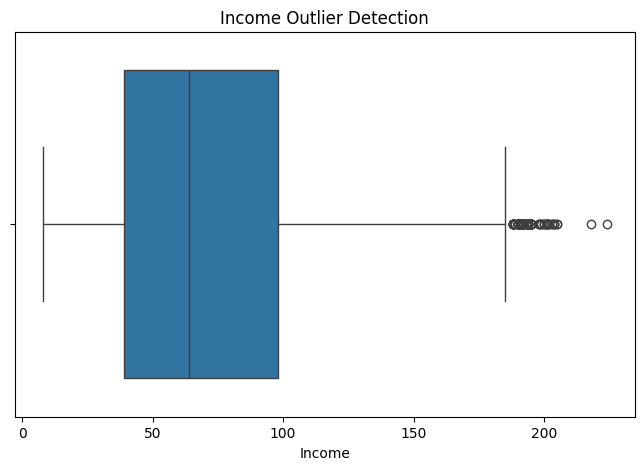

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df['Income'])

plt.title("Income Outlier Detection")
plt.xlabel("Income")
plt.show()

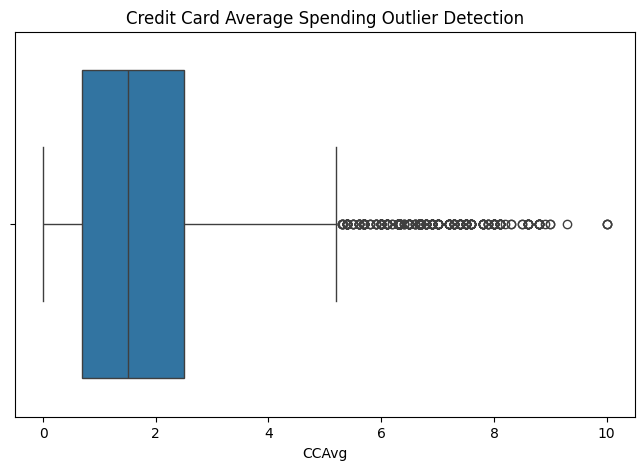

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df['CCAvg'])

plt.title("Credit Card Average Spending Outlier Detection")
plt.xlabel("CCAvg")
plt.show()

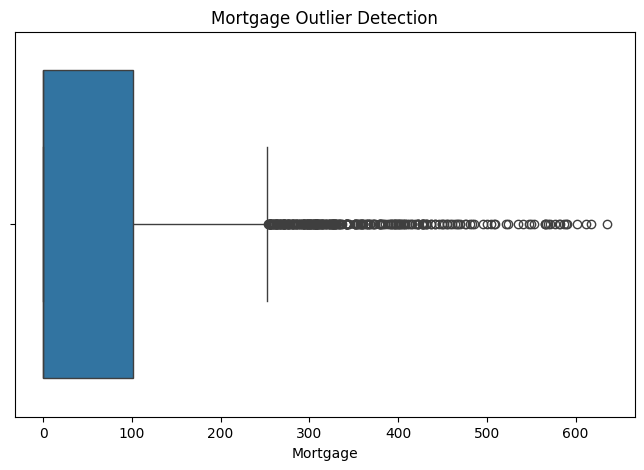

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df['Mortgage'])

plt.title("Mortgage Outlier Detection")
plt.xlabel("Mortgage")
plt.show()

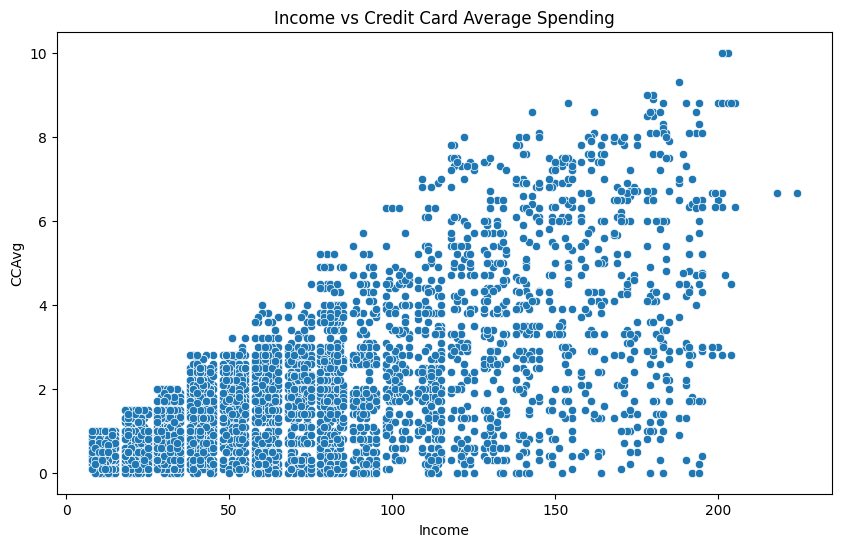

In [22]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Income',
    y='CCAvg'
)

plt.title("Income vs Credit Card Average Spending")
plt.xlabel("Income")
plt.ylabel("CCAvg")

plt.show()

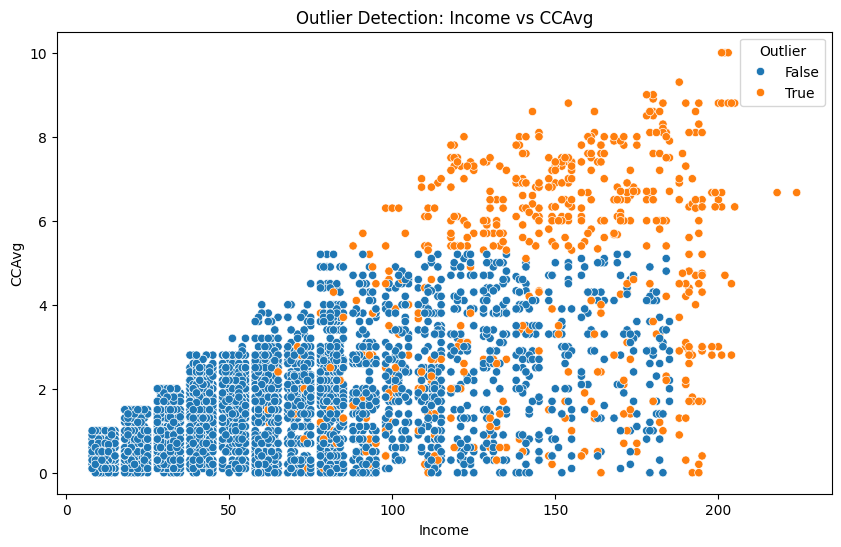

In [23]:
df['Outlier'] = outlier_mask.any(axis=1)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Income',
    y='CCAvg',
    hue='Outlier'
)

plt.title("Outlier Detection: Income vs CCAvg")
plt.xlabel("Income")
plt.ylabel("CCAvg")

plt.show()

In [24]:
print(df['Outlier'].value_counts())

Outlier
False    4398
True      602
Name: count, dtype: int64


In [25]:
outlier_percentage = df['Outlier'].mean() * 100

print("Outlier Percentage:",
      round(outlier_percentage, 2), "%")

Outlier Percentage: 12.04 %
